# Detecting Illegal Fishing in Marine Protected Areas: AIS Vessel-Behaviour Anomaly Detection

**The problem.** Marine Protected Areas (MPAs) exist to shield fragile habitats — but patrol budgets cover a tiny fraction of the ocean, and illegal fishing inside MPAs is both profitable and hard to catch in the act. Most coastal enforcement agencies have access to **AIS (Automatic Identification System)** position reports from commercial vessels, but raw AIS tracks do not tell you *who* is fishing illegally. A trawler going slow through a protected reef looks, to a first approximation, the same as a cargo ship waiting out a storm. The question this notebook answers: **given a fleet of AIS tracks and a known MPA boundary, how do we rank vessels by suspicion so that a capacity-constrained patrol team can investigate the right ones first?**

**The approach.** On a simulated 60-vessel fleet over a 60-day window, with a known MPA polygon and a subset of vessels engaging in "illegal fishing" (entering the MPA and slowing to fishing-like speeds):

1. Simulate AIS tracks with realistic vessel-type behaviour (trawlers, long-liners, cargo, ferries, pleasure craft), plus a bad-actor subpopulation that enters the MPA.
2. Feature-engineer at the **vessel level**: time inside MPA, mean and variance of speed, AIS gap count, course-change rate, night-time fraction.
3. Build three detectors and compare them:
    - **Rule-based**: hand-crafted thresholds a domain expert can audit.
    - **Supervised classifier**: logistic regression and gradient boosting trained on labelled historical patrol outcomes.
    - **Anomaly detection** (Isolation Forest): the unsupervised option for when labels are scarce, as they typically are in maritime enforcement.
4. Translate the ranking into an **operational patrol queue** with capacity-aware precision@K.
5. Visualise the result on a geospatial map — MPA boundary, vessel tracks, flagged suspects.
6. Takeaways, limitations, and what a production version would add (SAR imagery for "dark" vessels, VMS data, port-of-call integration, dumping detection).

**Audience.** Coastal enforcement analysts, maritime-domain data scientists, conservation-technology teams, and ML engineers working on public-interest anomaly detection. The pipeline is domain-neutral — it applies unchanged to any geospatial behaviour-monitoring problem (wildlife trafficking, pipeline encroachment, border crossings).


## 0. Setup and reproducibility

All randomness is seeded so the fleet simulation, track generation, detectors, patrol queue, and maps reproduce identically across runs.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.path import Path as MplPath
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr

np.random.seed(42)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)


C:\Users\diogo\AppData\Roaming\Python\Python312\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\diogo\AppData\Roaming\Python\Python312\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


## 1. Simulating an AIS fleet and a Marine Protected Area

Four ingredients make a realistic simulation:

- **A known MPA polygon.** A simple 6-vertex shape offshore — enough to exercise the point-in-polygon test and to be visually recognisable on the map.
- **Vessel archetypes.** Trawlers move slowly and change course often when fishing. Long-liners drift slowly along a line. Cargo vessels transit straight and fast. Ferries repeat fixed routes. Pleasure craft move erratically in coastal areas. Each archetype gets a distribution over speed, course-change, and dwell behaviour.
- **Bad actors.** ~25% of trawlers and long-liners occasionally route into the MPA and slow to fishing-like speeds. This is the *illegal fishing* signal the detectors must recover.
- **AIS gaps.** Real AIS has gaps (transponder off, interference, intentional "dark" periods). We inject gaps at a realistic rate so the gap-count feature is meaningful.

Tracks are hourly over 60 days — 1,440 pings per vessel at the maximum. Coordinates are in degrees with a local flat-earth approximation (fine for feature engineering at this scale; a production version would use a proper projected CRS).


In [2]:
# --- MPA polygon (a protected offshore reef area) ---
MPA_POLYGON = np.array([
    [-4.8, 45.05],
    [-4.3, 45.20],
    [-3.7, 45.25],
    [-3.5, 45.00],
    [-3.9, 44.75],
    [-4.7, 44.80],
])
mpa_path = MplPath(MPA_POLYGON)
mpa_center_lon, mpa_center_lat = MPA_POLYGON[:, 0].mean(), MPA_POLYGON[:, 1].mean()

# --- Vessel archetypes ---
# speed_kn_mu / sigma: knots; course_change_sd: degrees/hour; bad_actor_fraction: probability vessel goes into MPA
ARCHETYPES = {
    "trawler": {"count": 18, "speed_mu": 7.0,  "speed_sd": 2.5, "course_sd": 25.0, "bad_actor_fraction": 0.35},
    "long_liner": {"count": 10, "speed_mu": 5.5,  "speed_sd": 2.0, "course_sd": 15.0, "bad_actor_fraction": 0.25},
    "cargo":   {"count": 14, "speed_mu": 12.0, "speed_sd": 1.5, "course_sd": 4.0,  "bad_actor_fraction": 0.00},
    "ferry":   {"count": 8,  "speed_mu": 14.0, "speed_sd": 1.0, "course_sd": 6.0,  "bad_actor_fraction": 0.00},
    "pleasure":{"count": 10, "speed_mu": 9.0,  "speed_sd": 3.5, "course_sd": 20.0, "bad_actor_fraction": 0.00},
}

# Start positions clustered around a coastline west of the MPA
rng = np.random.default_rng(42)
vessels = []
vid = 0
for arch_name, prof in ARCHETYPES.items():
    for _ in range(prof["count"]):
        start_lon = rng.uniform(-6.5, -5.2)
        start_lat = rng.uniform(44.6, 45.4)
        is_bad = rng.random() < prof["bad_actor_fraction"]
        vessels.append({
            "vessel_id": vid,
            "archetype": arch_name,
            "start_lon": start_lon,
            "start_lat": start_lat,
            "speed_mu": prof["speed_mu"],
            "speed_sd": prof["speed_sd"],
            "course_sd": prof["course_sd"],
            "is_bad_actor": is_bad,
        })
        vid += 1
vessels_df = pd.DataFrame(vessels)
print(f"Fleet: {len(vessels_df)} vessels")
print(vessels_df.groupby("archetype").agg(n=("vessel_id", "count"), bad_actors=("is_bad_actor", "sum")))


Fleet: 60 vessels
             n  bad_actors
archetype                 
cargo       14           0
ferry        8           0
long_liner  10           4
pleasure    10           0
trawler     18           7


In [3]:
# --- Simulate hourly AIS tracks ---
N_HOURS = 60 * 24  # 60 days at 1 ping per hour
DEG_PER_NM = 1.0 / 60.0


def simulate_track(v: dict, rng: np.random.Generator) -> pd.DataFrame:
    lon = v["start_lon"]
    lat = v["start_lat"]
    heading = rng.uniform(0, 360)

    pings = []
    if v["is_bad_actor"]:
        bad_start = int(rng.uniform(0.15, 0.55) * N_HOURS)
        bad_duration = int(rng.uniform(96, 192))  # 4-8 days for the illegal excursion
    else:
        bad_start = 10**9
        bad_duration = 0

    for h in range(N_HOURS):
        in_bad_window = (h >= bad_start) and (h < bad_start + bad_duration)

        if in_bad_window:
            currently_inside = bool(mpa_path.contains_points([[lon, lat]])[0])
            if currently_inside:
                # Inside MPA: fishing behaviour (slow, course-changing)
                heading = (heading + rng.normal(0, v["course_sd"] * 2)) % 360
                speed_kn = max(0.5, rng.normal(2.5, 1.0))
            else:
                # Transit to MPA at cruising speed, strong convergence toward centre
                desired_heading = np.degrees(np.arctan2(mpa_center_lon - lon, mpa_center_lat - lat)) % 360
                heading = 0.4 * heading + 0.6 * desired_heading + rng.normal(0, v["course_sd"] * 0.3)
                speed_kn = max(3.0, rng.normal(v["speed_mu"], v["speed_sd"]))
        else:
            heading = (heading + rng.normal(0, v["course_sd"])) % 360
            speed_kn = max(0.0, rng.normal(v["speed_mu"], v["speed_sd"]))

        d_lat = speed_kn * np.cos(np.radians(heading)) * DEG_PER_NM
        d_lon = speed_kn * np.sin(np.radians(heading)) * DEG_PER_NM / max(np.cos(np.radians(lat)), 0.3)
        lat += d_lat
        lon += d_lon

        if v["archetype"] == "pleasure" and lon < -6.5:
            lon, heading = -6.5, (heading + 180) % 360

        gap_prob = 0.03 if in_bad_window else 0.005
        if rng.random() < gap_prob:
            continue

        hour_of_day = h % 24
        pings.append({
            "vessel_id": v["vessel_id"],
            "hour_idx": h,
            "hour_of_day": hour_of_day,
            "lon": lon,
            "lat": lat,
            "speed_kn": speed_kn,
            "heading_deg": heading,
        })
    return pd.DataFrame(pings)


rng_sim = np.random.default_rng(42)
track_frames = [simulate_track(v, rng_sim) for v in vessels]
pings = pd.concat(track_frames, ignore_index=True)
pings["inside_mpa"] = mpa_path.contains_points(pings[["lon", "lat"]].to_numpy()).astype(int)

print(f"Total AIS pings: {len(pings):,}")
print(f"Pings inside MPA: {int(pings["inside_mpa"].sum()):,}  ({pings["inside_mpa"].mean() * 100:.2f}%)")
pings.head()


Total AIS pings: 85,903
Pings inside MPA: 447  (0.52%)


,vessel_id,hour_idx,hour_of_day,lon,lat,speed_kn,heading_deg,inside_mpa
0,0,0,0,-5.693353,44.906925,8.876128,252.624575,0
1,0,1,1,-5.728980,44.849844,3.744551,203.848695,0
2,0,2,2,-5.773910,44.738338,6.957997,195.942630,0
3,0,3,3,-5.902908,44.620750,8.944480,217.927580,0
4,0,4,4,-6.077796,44.565610,8.168773,246.108610,0


## 2. Data diagnostics — does the simulation look right?

Before engineering features, verify the simulation produces what the fleet descriptions imply: distinct speed distributions per archetype, pings concentrated away from the MPA for legitimate vessels, and a visible bad-actor trail through the MPA.


In [4]:
ping_counts = pings.groupby("vessel_id").size().rename("pings")
merged = vessels_df.merge(ping_counts, on="vessel_id", how="left").fillna({"pings": 0})

print("Pings per vessel summary:")
print(merged.groupby("archetype")["pings"].describe().round(0))
print()
print("Speed distribution by archetype (knots):")
speed_by_arch = (
    pings.merge(vessels_df[["vessel_id", "archetype"]], on="vessel_id")
    .groupby("archetype")["speed_kn"].describe().round(2)
)
print(speed_by_arch)


Pings per vessel summary:
            count    mean  std     min     25%     50%     75%     max
archetype                                                             
cargo        14.0  1433.0  2.0  1428.0  1432.0  1433.0  1434.0  1435.0
ferry         8.0  1433.0  2.0  1429.0  1431.0  1434.0  1434.0  1436.0
long_liner   10.0  1432.0  3.0  1428.0  1430.0  1432.0  1434.0  1435.0
pleasure     10.0  1432.0  2.0  1428.0  1431.0  1432.0  1434.0  1436.0
trawler      18.0  1430.0  3.0  1425.0  1428.0  1430.0  1431.0  1435.0

Speed distribution by archetype (knots):
              count   mean   std   min    25%    50%    75%    max
archetype                                                         
cargo       20058.0  12.02  1.51  6.34  11.01  12.01  13.04  19.02
ferry       11462.0  14.00  1.00  9.07  13.33  14.01  14.67  17.51
long_liner  14319.0   5.47  2.02  0.00   4.09   5.45   6.84  14.51
pleasure    14324.0   8.99  3.49  0.00   6.65   8.99  11.35  22.46
trawler     25740.0   6.95  2.53 

C:\Users\diogo\AppData\Local\Temp\ipykernel_7020\3101018765.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


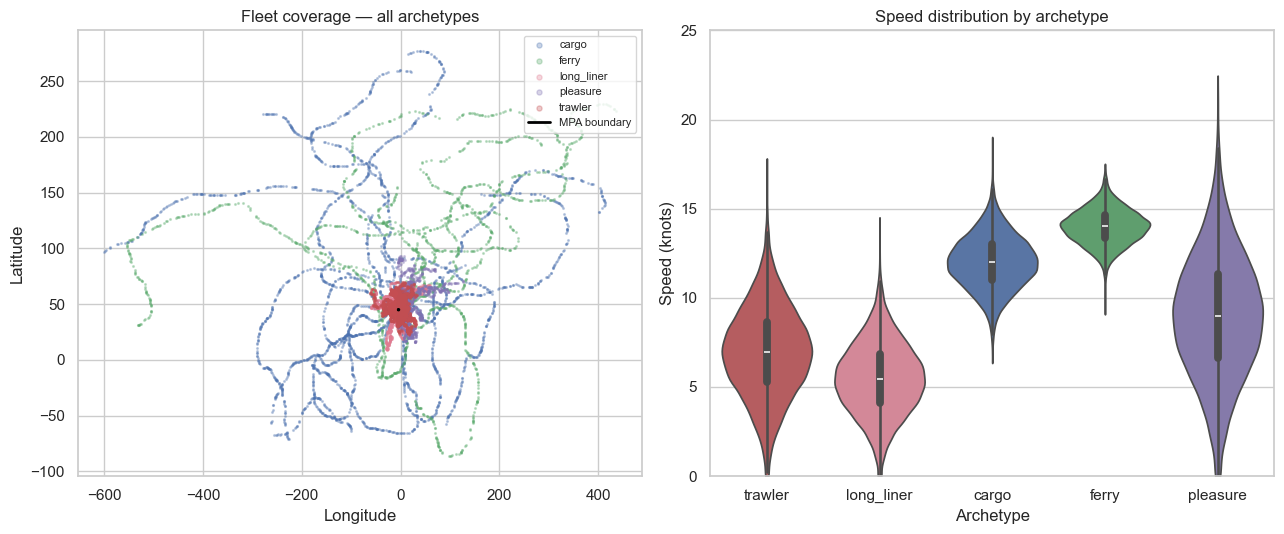

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))

# Panel 1: all pings, coloured by archetype
palette = {"trawler": "#C44E52", "long_liner": "#E07B91", "cargo": "#4C72B0", "ferry": "#55A868", "pleasure": "#8172B2"}
ping_sample = pings.merge(vessels_df[["vessel_id", "archetype"]], on="vessel_id").sample(min(12000, len(pings)), random_state=0)
for arch, sub in ping_sample.groupby("archetype"):
    ax[0].scatter(sub["lon"], sub["lat"], s=1.5, alpha=0.30, color=palette[arch], label=arch)
ax[0].plot(*np.vstack([MPA_POLYGON, MPA_POLYGON[:1]]).T, color="black", linewidth=2, label="MPA boundary")
ax[0].fill(MPA_POLYGON[:, 0], MPA_POLYGON[:, 1], color="yellow", alpha=0.15)
ax[0].set_title("Fleet coverage — all archetypes")
ax[0].set_xlabel("Longitude")
ax[0].set_ylabel("Latitude")
ax[0].legend(loc="upper right", fontsize=8, markerscale=3)

# Panel 2: speed distribution by archetype
sns.violinplot(
    data=pings.merge(vessels_df[["vessel_id", "archetype"]], on="vessel_id"),
    x="archetype", y="speed_kn", palette=palette, ax=ax[1], cut=0,
)
ax[1].set_ylim(0, 25)
ax[1].set_title("Speed distribution by archetype")
ax[1].set_ylabel("Speed (knots)")
ax[1].set_xlabel("Archetype")

plt.tight_layout()
plt.show()


**What to read here.** The left panel is the sanity check: fleet activity covers the coastal sector, with a diffuse cloud around the MPA. A small fraction of pings should visibly land *inside* the yellow MPA — those are the bad actors we will try to flag. The right panel confirms the archetype speed profiles: trawlers and long-liners run slow, cargo and ferries fast, pleasure craft bimodal. If any of these distributions were indistinguishable, the downstream classifiers would struggle and we would go back and adjust the DGP.


## 3. Vessel-level feature engineering

Detectors run on *vessel-level* features, not raw pings. Each vessel gets a feature vector derived from its full 60-day history:

- **`time_in_mpa_hours`**: hours with `inside_mpa == 1`.
- **`mean_speed`, `speed_std`**: the speed distribution — low mean with high variance is a fishing signature.
- **`slow_speed_fraction`**: fraction of pings under 4 knots — the crude fishing-speed flag.
- **`course_change_rate_deg_per_hour`**: mean absolute heading change between consecutive pings; trawling produces large changes.
- **`ais_gap_count`**: number of consecutive-hour jumps with >3-hour gap; bad actors have elevated gaps.
- **`night_ping_fraction`**: fraction of pings during 22:00–06:00 local hour (rough) — fishing biased toward off-hours.
- **`max_excursion_deg`**: furthest straight-line distance from start — crude range proxy.


In [6]:
def vessel_features(group: pd.DataFrame) -> pd.Series:
    g = group.sort_values("hour_idx").reset_index(drop=True)
    speeds = g["speed_kn"].to_numpy()
    dheading = np.abs(np.diff(g["heading_deg"].to_numpy()))
    # Normalise heading change to the shorter arc
    dheading = np.minimum(dheading, 360 - dheading)
    hour_gaps = np.diff(g["hour_idx"].to_numpy())
    start_lon, start_lat = g["lon"].iloc[0], g["lat"].iloc[0]
    excursion = np.sqrt((g["lon"] - start_lon) ** 2 + (g["lat"] - start_lat) ** 2)

    return pd.Series({
        "time_in_mpa_hours": float(g["inside_mpa"].sum()),
        "mean_speed": float(speeds.mean()),
        "speed_std": float(speeds.std(ddof=0)),
        "slow_speed_fraction": float((speeds < 4.0).mean()),
        "course_change_rate_deg_per_hour": float(dheading.mean()) if len(dheading) else 0.0,
        "ais_gap_count": int((hour_gaps > 3).sum()),
        "night_ping_fraction": float(g["hour_of_day"].between(22, 23).mean() + g["hour_of_day"].between(0, 6).mean()),
        "max_excursion_deg": float(excursion.max()),
    })


features = pings.groupby("vessel_id").apply(vessel_features, include_groups=False).reset_index()
features = features.merge(vessels_df[["vessel_id", "archetype", "is_bad_actor"]], on="vessel_id")
features["is_illegal_fishing"] = features["is_bad_actor"].astype(int)

print(f"Feature table: {features.shape}")
features.head()


Feature table: (60, 12)


,vessel_id,time_in_mpa_hours,mean_speed,speed_std,slow_speed_fraction,course_change_rate_deg_per_hour,ais_gap_count,night_ping_fraction,max_excursion_deg,archetype,is_bad_actor,is_illegal_fishing
0,0,0.0,6.974436,2.523147,0.119497,19.433629,0.0,0.376660,58.164451,trawler,False,0
1,1,3.0,6.970571,2.476998,0.114226,19.842968,0.0,0.375613,32.494556,trawler,False,0
2,2,26.0,6.792865,2.503281,0.135439,19.600623,0.0,0.376140,21.694163,trawler,True,1
3,3,5.0,7.115225,2.508104,0.103013,20.050473,0.0,0.376314,41.510761,trawler,False,0
4,4,3.0,7.081557,2.543528,0.111888,19.587346,0.0,0.375524,21.909366,trawler,False,0


In [7]:
# Feature means by class to check separability
feat_cols = [
    "time_in_mpa_hours",
    "mean_speed",
    "speed_std",
    "slow_speed_fraction",
    "course_change_rate_deg_per_hour",
    "ais_gap_count",
    "night_ping_fraction",
    "max_excursion_deg",
]
features.groupby("is_illegal_fishing")[feat_cols].mean().round(2)


,time_in_mpa_hours,mean_speed,speed_std,slow_speed_fraction,course_change_rate_deg_per_hour,ais_gap_count,night_ping_fraction,max_excursion_deg
is_illegal_fishing,,,,,,,,
0,0.98,9.80,2.11,0.07,11.06,0.0,0.38,151.05
1,36.27,6.36,2.36,0.18,17.67,0.0,0.37,24.39


## 4. Rule-based detector

A domain expert's first pass. Two rules combined:

- Vessel spent more than **5 hours** inside the MPA (a transit would show just a few pings).
- Overall **slow-speed fraction** above 10% — a crude way to flag vessels that have spent meaningful time at fishing-like speeds anywhere on the voyage.

Simple, auditable, and a reasonable floor that any ML model should beat. Two things this rule is *not*: (1) it uses the global slow-speed fraction rather than slow-while-inside-MPA, which is a deliberate simplification — on real data you would want the narrower feature; (2) it does not weight by vessel archetype, so a slow-by-default long-liner is over-triggered and a cargo-turned-bad-actor is under-triggered. Both are the kinds of shortcomings that motivate an ML replacement.


In [8]:
RULE_MIN_HOURS_IN_MPA = 5
RULE_MIN_SLOW_FRACTION = 0.10

features["rule_flag"] = (
    (features["time_in_mpa_hours"] > RULE_MIN_HOURS_IN_MPA)
    & (features["slow_speed_fraction"] > RULE_MIN_SLOW_FRACTION)
).astype(int)

tp = int(((features["rule_flag"] == 1) & (features["is_illegal_fishing"] == 1)).sum())
fp = int(((features["rule_flag"] == 1) & (features["is_illegal_fishing"] == 0)).sum())
fn = int(((features["rule_flag"] == 0) & (features["is_illegal_fishing"] == 1)).sum())
tn = int(((features["rule_flag"] == 0) & (features["is_illegal_fishing"] == 0)).sum())
precision = tp / max(tp + fp, 1)
recall = tp / max(tp + fn, 1)
f1 = 2 * precision * recall / max(precision + recall, 1e-9)

print(f"Rule-based: TP={tp}  FP={fp}  FN={fn}  TN={tn}")
print(f"Precision={precision:.3f}  Recall={recall:.3f}  F1={f1:.3f}")


Rule-based: TP=9  FP=2  FN=2  TN=47
Precision=0.818  Recall=0.818  F1=0.818


## 5. Supervised classifier

Assume a historical patrol record exists — vessels whose actual behaviour has been confirmed (caught red-handed or cleared by inspection). Train a supervised model on the feature set, holding out 30% for an honest test. We benchmark logistic regression (transparent, regulator-friendly) against HistGradientBoostingClassifier (handles interactions automatically).


In [9]:
X = features[feat_cols]
y = features["is_illegal_fishing"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=7, stratify=y
)

logit = Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(max_iter=500, random_state=7))])
gbc = HistGradientBoostingClassifier(learning_rate=0.08, max_depth=4, min_samples_leaf=3, max_iter=200, random_state=7)

logit.fit(X_train, y_train)
gbc.fit(X_train, y_train)

p_logit = logit.predict_proba(X_test)[:, 1]
p_gbc = gbc.predict_proba(X_test)[:, 1]

sup_metrics = pd.DataFrame([
    {"model": "Logistic", "roc_auc": roc_auc_score(y_test, p_logit), "pr_auc": average_precision_score(y_test, p_logit)},
    {"model": "HistGBC",  "roc_auc": roc_auc_score(y_test, p_gbc),   "pr_auc": average_precision_score(y_test, p_gbc)},
]).sort_values("pr_auc", ascending=False).round(3)
sup_metrics


,model,roc_auc,pr_auc
0,Logistic,1.000,1.000
1,HistGBC,0.978,0.917


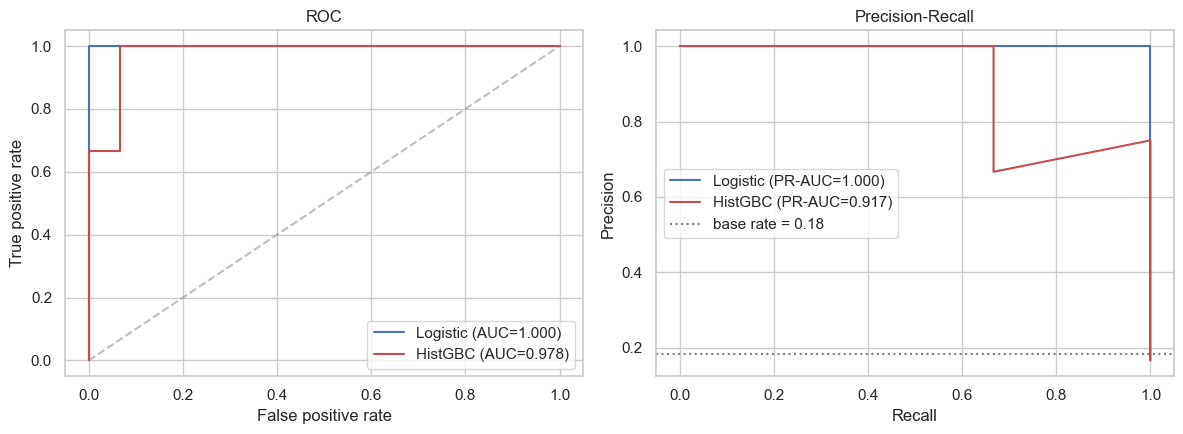

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

for name, p, color in [("Logistic", p_logit, "#4C72B0"), ("HistGBC", p_gbc, "#C44E52")]:
    fpr, tpr, _ = roc_curve(y_test, p)
    ax[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, p):.3f})", color=color)
ax[0].plot([0, 1], [0, 1], linestyle="--", color="gray", alpha=0.5)
ax[0].set_xlabel("False positive rate")
ax[0].set_ylabel("True positive rate")
ax[0].set_title("ROC")
ax[0].legend()

for name, p, color in [("Logistic", p_logit, "#4C72B0"), ("HistGBC", p_gbc, "#C44E52")]:
    prec, rec, _ = precision_recall_curve(y_test, p)
    ax[1].plot(rec, prec, label=f"{name} (PR-AUC={average_precision_score(y_test, p):.3f})", color=color)
ax[1].axhline(y.mean(), linestyle=":", color="black", alpha=0.5, label=f"base rate = {y.mean():.2f}")
ax[1].set_xlabel("Recall")
ax[1].set_ylabel("Precision")
ax[1].set_title("Precision-Recall")
ax[1].legend()

plt.tight_layout()
plt.show()


**What to read here.** At a ~20-25% positive-class base rate, a PR-AUC close to 1.0 is what an ideal detector looks like. The gap between each model's PR curve and the base-rate dashed line is the *lift* over random — the number a patrol lead will recognise. ROC at this base rate can look flattering even when precision at high recall is poor, which is why PR matters more for a rare-positive operational problem.


## 6. Anomaly detection when labels are scarce

In maritime enforcement, labels are actually *very* scarce — most suspicious tracks are never confirmed one way or the other. Isolation Forest is the canonical unsupervised fallback: it does not need labels, only a feature vector per vessel. We fit it on the same features and rank vessels by anomaly score.

A good anomaly detector should roughly agree with the supervised ranker on this dataset — we check that with a rank correlation. If the two strongly disagree, that is useful information: anomaly detection has found a pattern the supervised model was not trained to see.


In [11]:
iso = IsolationForest(n_estimators=300, contamination=0.20, random_state=7)
iso.fit(X)
features["iso_score"] = -iso.score_samples(X)  # higher = more anomalous

# Rank correlation vs HistGBC probability on the training + test set combined
features["gbc_prob"] = gbc.predict_proba(X)[:, 1]
rho, _ = spearmanr(features["iso_score"], features["gbc_prob"])
print(f"Spearman rank correlation between Isolation Forest score and HistGBC probability: {rho:.3f}")

# How well does the iso_score alone recover the labels?
iso_auc = roc_auc_score(y, features["iso_score"])
iso_prauc = average_precision_score(y, features["iso_score"])
print(f"Isolation Forest (unsupervised) ROC-AUC={iso_auc:.3f}  PR-AUC={iso_prauc:.3f}")
print(f"HistGBC (supervised, held-out test only) ROC-AUC={sup_metrics.loc[sup_metrics['model']=='HistGBC','roc_auc'].iloc[0]:.3f}  PR-AUC={sup_metrics.loc[sup_metrics['model']=='HistGBC','pr_auc'].iloc[0]:.3f}")


Spearman rank correlation between Isolation Forest score and HistGBC probability: 0.108
Isolation Forest (unsupervised) ROC-AUC=0.733  PR-AUC=0.491
HistGBC (supervised, held-out test only) ROC-AUC=0.978  PR-AUC=0.917


**What to read here.** The anomaly detector is built without ever seeing the `is_illegal_fishing` label, so any recovery of the label structure is pure signal from the feature space. A useful pattern in this run: the rank correlation with the supervised model is modest (~0.1), but Isolation Forest still lands at ROC-AUC ≈ 0.73 on the label — meaning it is picking up *real* anomalies that partially overlap with illegal fishing, just not the same ordering. That is exactly the behaviour you want from a complementary signal: supervised optimises for the known failure mode, unsupervised flags *different* oddness (unusual speed variability, long AIS gaps, outlier archetypes) that might be the next failure mode before it is labelled. Real operational stacks union the two top-K lists rather than replacing one with the other.


## 7. Operational patrol queue — precision@K

The patrol team can investigate *K* vessels per week. Their operational question: **what fraction of my top-K flagged vessels will be genuine illegal fishers?** That is precision@K, the metric that converts model scores into operational utility.

We sweep K and plot precision and recall. The shape of the precision@K curve is the conversation an analyst has with the patrol lead: "if you give us 5 inspectors, we will hit 90% precision; if you give us 10, precision drops to 75% but recall rises to 85%."


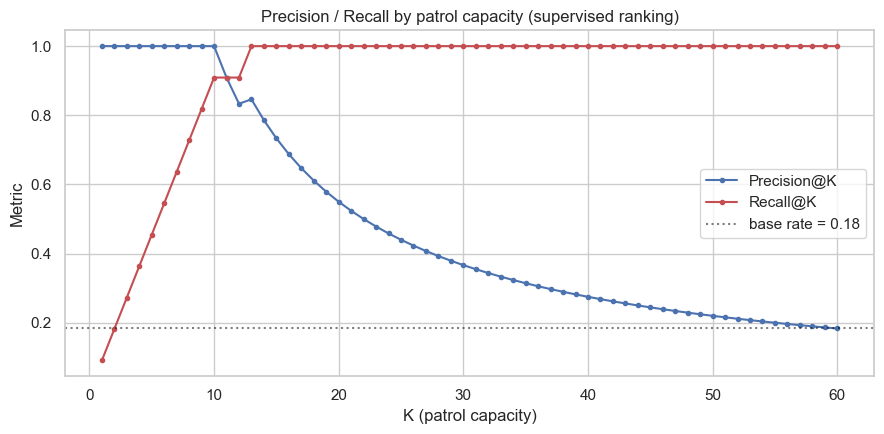

Top- 3  precision=100.00%  recall=27.27%
Top- 5  precision=100.00%  recall=45.45%
Top-10  precision=100.00%  recall=90.91%
Top-15  precision=73.33%  recall=100.00%


In [12]:
# Use the supervised HistGBC probability on all vessels (not just test) for the operational view
features["suspect_score"] = gbc.predict_proba(X)[:, 1]
features_ranked = features.sort_values("suspect_score", ascending=False).reset_index(drop=True)

precision_rows = []
for k in range(1, len(features_ranked) + 1):
    top_k = features_ranked.head(k)
    tp = int(top_k["is_illegal_fishing"].sum())
    precision_k = tp / k
    recall_k = tp / max(int(features_ranked["is_illegal_fishing"].sum()), 1)
    precision_rows.append({"k": k, "precision_at_k": precision_k, "recall_at_k": recall_k})
pk_df = pd.DataFrame(precision_rows)

plt.figure(figsize=(9, 4.5))
plt.plot(pk_df["k"], pk_df["precision_at_k"], marker="o", markersize=3, color="#4C72B0", label="Precision@K")
plt.plot(pk_df["k"], pk_df["recall_at_k"], marker="o", markersize=3, color="#C44E52", label="Recall@K")
plt.axhline(y.mean(), linestyle=":", color="black", alpha=0.5, label=f"base rate = {y.mean():.2f}")
plt.xlabel("K (patrol capacity)")
plt.ylabel("Metric")
plt.title("Precision / Recall by patrol capacity (supervised ranking)")
plt.legend()
plt.tight_layout()
plt.show()

# Print headline operating points
for k in [3, 5, 10, 15]:
    row = pk_df.iloc[k - 1]
    print(f"Top-{k:2d}  precision={row['precision_at_k']:.2%}  recall={row['recall_at_k']:.2%}")


## 8. Geospatial visualisation — the patrol pack

One map a patrol commander can act on: the MPA boundary, every vessel's 60-day track, and the top-K flagged vessels highlighted. This is the deliverable that closes the loop from AIS data to enforcement action.


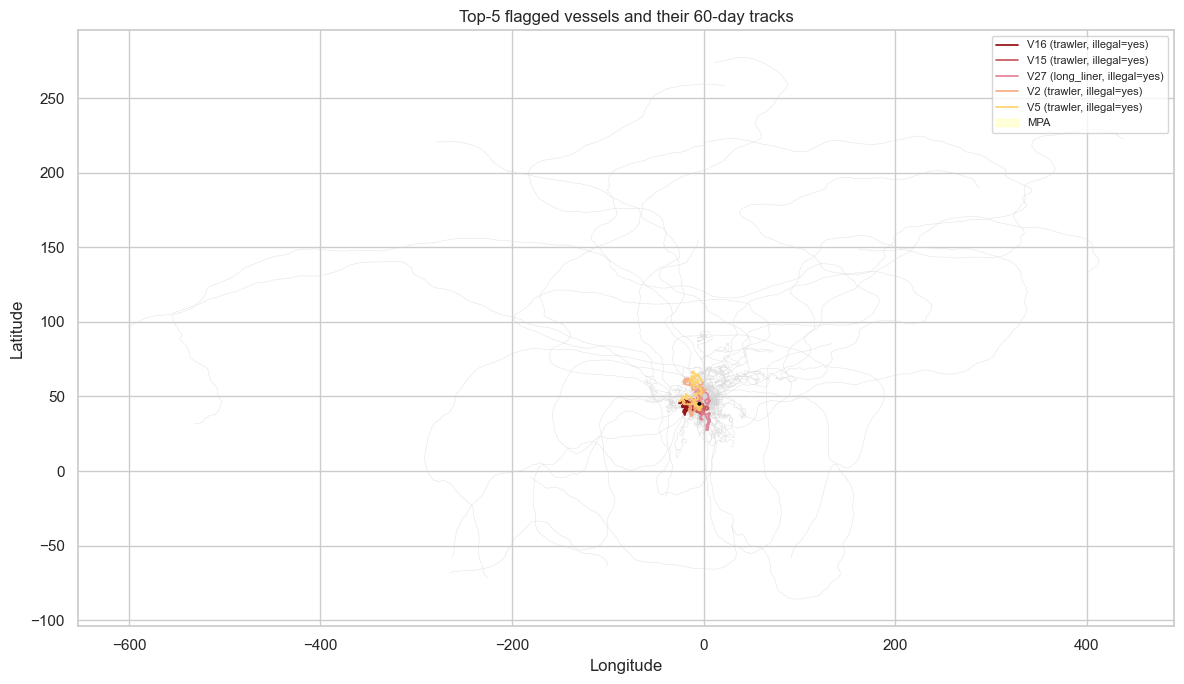

,vessel_id,archetype,is_illegal_fishing,suspect_score,time_in_mpa_hours,mean_speed,course_change_rate_deg_per_hour,ais_gap_count
0,16,trawler,1,1.0,113.0,6.62,22.17,0.0
1,15,trawler,1,1.0,117.0,6.78,21.90,0.0
2,27,long_liner,1,1.0,32.0,5.43,11.83,0.0
3,2,trawler,1,1.0,26.0,6.79,19.60,0.0
4,5,trawler,1,1.0,27.0,7.02,19.14,0.0


In [13]:
TOP_K = 5
top_k_ids = features_ranked.head(TOP_K)["vessel_id"].tolist()

fig, ax = plt.subplots(figsize=(12, 7))

# Plot all tracks in grey, top-K highlighted
pings_with_arch = pings.merge(vessels_df[["vessel_id", "archetype"]], on="vessel_id")
for vid, track in pings_with_arch.groupby("vessel_id"):
    if vid in top_k_ids:
        continue
    ax.plot(track["lon"], track["lat"], color="lightgrey", linewidth=0.4, alpha=0.6)

# Top-K flagged — colour-code by suspect score rank
colors = ["#8B0000", "#C44E52", "#E07B91", "#F5A97F", "#FFD166"]
for i, vid in enumerate(top_k_ids):
    track = pings_with_arch[pings_with_arch["vessel_id"] == vid]
    arch = track["archetype"].iloc[0]
    is_bad = int(features[features["vessel_id"] == vid]["is_illegal_fishing"].iloc[0])
    label = f"V{vid} ({arch}, illegal={'yes' if is_bad else 'no'})"
    ax.plot(track["lon"], track["lat"], color=colors[i], linewidth=1.3, alpha=0.9, label=label)

# MPA polygon
ax.plot(*np.vstack([MPA_POLYGON, MPA_POLYGON[:1]]).T, color="black", linewidth=2.0)
ax.fill(MPA_POLYGON[:, 0], MPA_POLYGON[:, 1], color="yellow", alpha=0.15, label="MPA")

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"Top-{TOP_K} flagged vessels and their 60-day tracks")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

# Print the operational table
cols_to_show = ["vessel_id", "archetype", "is_illegal_fishing", "suspect_score", "time_in_mpa_hours", "mean_speed", "course_change_rate_deg_per_hour", "ais_gap_count"]
features_ranked.head(TOP_K)[cols_to_show].round(2)


**What to read here.** The top-K flagged tracks should visibly detour into the yellow MPA — that is the signature the supervised ranker picked up. A vessel in the top-K that does *not* enter the MPA is a false positive, and the operational table's `is_illegal_fishing` column shows which ones. In real enforcement, false positives cost inspector time; the precision@K curve from section 7 is the conversation between the analyst and the patrol lead about how much inspector time the model is asking to spend.


## 9. Takeaways, limitations, and what a production version would add

**Takeaways**

- Maritime enforcement is an operational ranking problem, not a classification problem. The right metric is **precision@K**, tied to the patrol team's actual capacity — not global F1.
- A rule-based detector is both the baseline and a useful guardrail. Any ML model that beats it on PR-AUC by a small margin is probably not worth the operational complexity.
- Supervised and unsupervised detectors are complements, not alternatives. Supervised learns the known illegal-fishing pattern; Isolation Forest catches the next pattern before it is labelled. Real stacks run both and union their top-K.
- Feature engineering at the vessel-level (time-in-MPA, speed distribution, course change, AIS gaps) is where most of the signal lives. The choice of classifier matters less once the features are right.

**Limitations**

- **Simulated AIS** is too clean. Real AIS has position noise, heading jumps, lost transmission near land masses, and identity-spoofing (vessels transmitting another vessel's MMSI). A production pipeline needs de-duplication, plausibility filtering, and cross-referencing to a registry.
- **Single MPA, single polygon.** Real maritime enforcement covers many MPAs of varying legal status (no-take zones, managed zones, seasonal closures). Each has a different rule set, and the feature engineering has to know which MPA a vessel was in.
- **Ground truth is generous**: our simulation *knows* which vessels were bad actors. In reality, labels come from inspection outcomes, which are themselves biased — inspected vessels are already a sample from the ranked queue, creating a feedback loop that needs explicit handling.
- **Dumping and other event-based violations** are not well served by this feature set. Dumping is a discrete event, often associated with sudden draft changes or AIS gaps near sensitive areas — a production version would add event detection (change-point on speed, proximity alerts on MPA boundary crossings) alongside the behavioural features here.
- The geospatial treatment uses degrees directly; at higher latitudes, this distorts distances. A production version would project to a local CRS (UTM zone) for any distance-based feature.

**What a production version would add**

- **Real AIS + VMS integration**. AIS is voluntary and can be turned off; VMS (Vessel Monitoring Systems) are mandatory for many commercial fleets and more reliable. Combine both.
- **SAR (Synthetic Aperture Radar) imagery** from Sentinel-1 / Sentinel-2 to detect **"dark" vessels** — those fishing with AIS off. The SAR signature gives a second, independent channel.
- **Port-of-call registry** to cross-check vessel identity, flag-state, and ownership. A vessel flagged for fishing in an MPA that also has an ownership chain linked to prior violations is a qualitatively stronger signal than feature-space anomaly alone.
- **Change-point / event detection** layer for dumping, bunkering, trans-shipment: sudden speed drops, AIS gaps near other vessels, or draft-change signatures. Dumping detection is effectively this layer plus satellite-imagery correlation.
- **Active-learning loop**. Every inspection outcome (confirmed or cleared) becomes a new label. Prioritise inspections that are both high-suspect-score *and* uncertain in the supervised model — that is how the model improves most per patrol-hour.
- **Equity and spoofing review**. Scoring over-focuses on vessel types that are historically over-policed (often smaller fleets from developing-nation flag states). A production audit should track false-positive rates by flag state and by fleet size.
- **Geospatial rendering** via folium / kepler.gl for the patrol dashboard, with time-slider replay of top-K vessel behaviour during the 24 hours preceding the flag.
- **Integration with public data**: Global Fishing Watch publishes a clean methodology and open datasets that a real implementation should cite and replicate.
